# 三线综合 — 数值验证统一公式

配套 lecture: [../lectures/09-three-line-unification.md](../lectures/09-three-line-unification.md)

本 notebook 演示:
1. 数值证明 Parallel Adapter (σ=identity) = LoRA
2. 数值证明 (IA)³ ≡ diag(LoRA r=d)
3. 28 方法参数量横向表

In [1]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

src = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src))

## 1. 数值证明 Parallel(σ=id) ≡ LoRA

In [2]:
torch.manual_seed(0)
d, r = 16, 4
x = torch.randn(2, 5, d)

# 相同的 W_down, W_up
W_down = torch.randn(r, d) * 0.1
W_up = torch.randn(d, r) * 0.1

# Parallel Adapter without σ
out_parallel = x @ W_down.T @ W_up.T

# LoRA: ΔW = W_up @ W_down, output = x @ ΔW^T
delta_W = W_up @ W_down  # (d, d), rank=r
out_lora = x @ delta_W.T

diff = (out_parallel - out_lora).abs().max().item()
print(f'Parallel(σ=id) vs LoRA: max|Δ| = {diff:.4e}')
print(f'ΔW rank: {torch.linalg.matrix_rank(delta_W).item()} = r = {r}')
print(f'\n→ 严格相等：Parallel Adapter 去掉 σ = LoRA')

Parallel(σ=id) vs LoRA: max|Δ| = 4.4703e-08
ΔW rank: 4 = r = 4

→ 严格相等：Parallel Adapter 去掉 σ = LoRA


## 2. 数值证明 (IA)³ ≡ diag(LoRA r=d)

In [3]:
# (IA)³ 公式: y = x * l (element-wise)
# 等价于: y = x * diag(l) (矩阵乘法)
# 等价于: y = x @ W where W = diag(l) (a rank-d "LoRA" with B=I, A=diag(l-1))

torch.manual_seed(0)
d = 16
x = torch.randn(2, 5, d)
l = torch.rand(d) + 0.5  # 随机缩放向量 (0.5-1.5)

# (IA)³ forward
out_ia3 = x * l

# Equivalent: x @ diag(l)^T
W_diag = torch.diag(l)
out_diag = x @ W_diag.T

diff = (out_ia3 - out_diag).abs().max().item()
print(f'(IA)^3 vs diag matrix mult: max|Δ| = {diff:.4e}')
print(f'\n→ (IA)^3 等价于用对角矩阵做线性变换')
print(f'→ rank(diag(l)) = {d} = full rank')
print(f'→ 但只有 d 个参数，比 LoRA r=8 (d * 2r = 16 * 16 = 256) 还少')

(IA)^3 vs diag matrix mult: max|Δ| = 0.0000e+00

→ (IA)^3 等价于用对角矩阵做线性变换
→ rank(diag(l)) = 16 = full rank
→ 但只有 d 个参数，比 LoRA r=8 (d * 2r = 16 * 16 = 256) 还少


## 3. 28 方法参数量横向表

C:\Users\ericp\AppData\Local\Temp\ipykernel_37384\857872972.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)
C:\Users\ericp\AppData\Local\Temp\ipykernel_37384\857872972.py:51: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_37384\857872972.py:51: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_37384\857872972.py:51: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_37384\857872972.py:51: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt

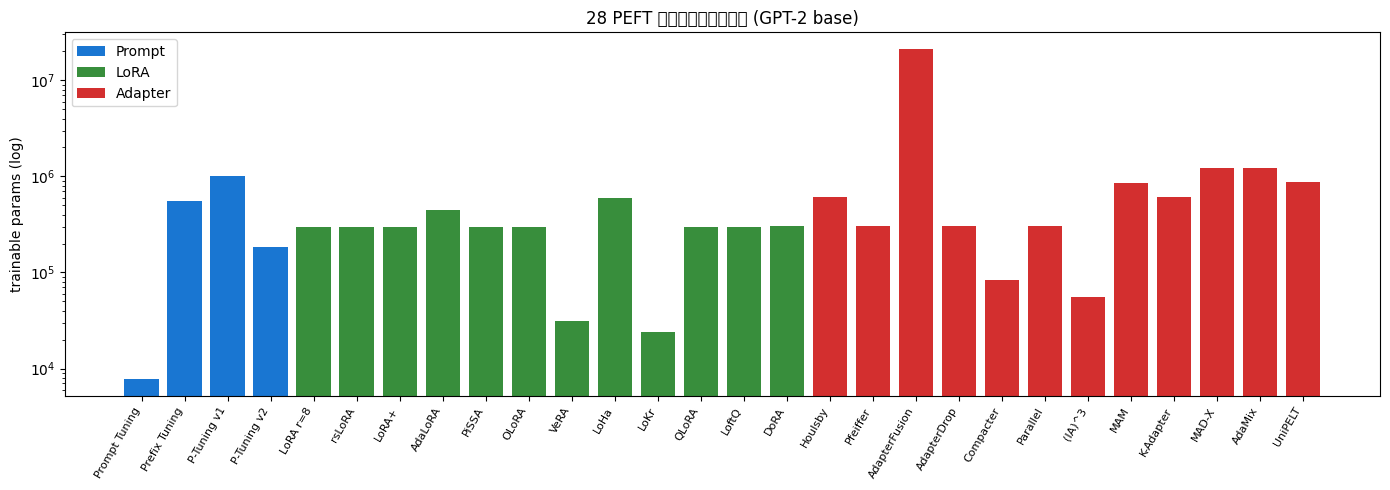

In [4]:
# 假设 GPT-2 base (d=768, 12 layer)
data = [
    # (name, 主线, 参数量)
    ('Prompt Tuning',  'Prompt',  7700),
    ('Prefix Tuning',  'Prompt',  553000),
    ('P-Tuning v1',    'Prompt',  1000000),
    ('P-Tuning v2',    'Prompt',  184000),
    ('LoRA r=8',       'LoRA',    295000),
    ('rsLoRA',         'LoRA',    295000),
    ('LoRA+',          'LoRA',    295000),
    ('AdaLoRA',        'LoRA',    442000),
    ('PiSSA',          'LoRA',    295000),
    ('OLoRA',          'LoRA',    295000),
    ('VeRA',           'LoRA',    31000),
    ('LoHa',           'LoRA',    590000),
    ('LoKr',           'LoRA',    24000),
    ('QLoRA',          'LoRA',    295000),
    ('LoftQ',          'LoRA',    295000),
    ('DoRA',           'LoRA',    304000),
    ('Houlsby',        'Adapter', 609000),
    ('Pfeiffer',       'Adapter', 304000),
    ('AdapterFusion',  'Adapter', 21233000),
    ('AdapterDrop',    'Adapter', 304000),
    ('Compacter',      'Adapter', 83000),
    ('Parallel',       'Adapter', 304000),
    ('(IA)^3',         'Adapter', 55000),
    ('MAM',            'Adapter', 857000),
    ('K-Adapter',      'Adapter', 609000),
    ('MAD-X',          'Adapter', 1222000),
    ('AdaMix',         'Adapter', 1217000),
    ('UniPELT',        'Adapter', 880000),
]

color_map = {'Prompt': '#1976d2', 'LoRA': '#388e3c', 'Adapter': '#d32f2f'}

names = [d[0] for d in data]
lines = [d[1] for d in data]
params = [d[2] for d in data]
colors = [color_map[l] for l in lines]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(names, params, color=colors)
ax.set_yscale('log')
ax.set_ylabel('trainable params (log)')
ax.set_title('28 PEFT 方法参数量横向对比 (GPT-2 base)')
ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[l], label=l) for l in ['Prompt', 'LoRA', 'Adapter']]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout(); plt.show()

## 4. 工程选型决策（互动）

In [5]:
def recommend(scenario: str):
    """基于场景给 PEFT 推荐。"""
    recs = {
        '65B 单卡 24GB': 'QLoRA',
        '极致省参数': '(IA)^3 / VeRA',
        '推理零时延': 'LoRA / DoRA',
        'NER 序列标注': 'P-Tuning v2',
        '多语言迁移': 'MAD-X',
        '多模态': 'LLaMA-Adapter / Q-Former',
        '追求最高质量': 'DoRA / MAM',
        '科研迭代快': 'PiSSA',
        'Few-shot': '(IA)^3',
        '多任务千用户': 'VeRA',
        'Stable Diffusion': 'LoKr',
    }
    return recs.get(scenario, 'LoRA r=8 (默认)')

scenarios = [
    '65B 单卡 24GB',
    '极致省参数',
    '推理零时延',
    'NER 序列标注',
    '多语言迁移',
    '多模态',
]
print(f'{"场景":<20}{"推荐方法":<30}')
print('-' * 50)
for s in scenarios:
    print(f'{s:<20}{recommend(s):<30}')

场景                  推荐方法                          
--------------------------------------------------
65B 单卡 24GB         QLoRA                         
极致省参数               (IA)^3 / VeRA                 
推理零时延               LoRA / DoRA                   
NER 序列标注            P-Tuning v2                   
多语言迁移               MAD-X                         
多模态                 LLaMA-Adapter / Q-Former      


## 5. 思考题

1. 用一句话告诉你的同事：PEFT 三大主线的本质相同点是什么？
2. 哪 5 个方法你认为是 PEFT 历史上最重要的？为什么？
3. 如果你只能记住一个统一公式，记 `h ← h + f(W_down·x) · W_up`，能用它解释 28 方法吗？

下节: **L10 PEFT 下一步**